In [9]:
# Cell 1: Environment Setup & Execution Configuration
import os
import sys
import re
import json
from pathlib import Path
import cv2
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split

# Ensure src/ is on sys.path to reuse doc_agent package modules directly
possible_src = [Path("../src"), Path("src"), Path("../../src")]
src_dir = next((d.resolve() for d in possible_src if (d / "doc_agent").is_dir()), None)
if src_dir and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from doc_agent.contracts import Page, Region
from doc_agent import config, wiring
from doc_agent.ingest import loader, preprocess
from doc_agent.vision import layout

# Ensure Windows console / notebooks handle Bengali UTF-8 encoding safely
if sys.stdout and hasattr(sys.stdout, 'reconfigure'):
    try:
        sys.stdout.reconfigure(encoding='utf-8', errors='replace')
    except Exception:
        pass

# -------------------------------------------------------------------------
# Execution Configuration: Full Scan across all 704 pages (Direct Layout)
# -------------------------------------------------------------------------
# Resolve RAW_DATA_DIR relative to notebook or repo root
possible_dirs = [Path("../data/raw"), Path("data/raw"), Path("data")]
RAW_DATA_DIR = next((d for d in possible_dirs if d.is_dir() and any(d.glob("*.png"))), Path("../data/raw"))

print(f"[Setup] Raw Data Directory : {RAW_DATA_DIR.resolve()}")
print(f"[Setup] Package Source Dir : {src_dir}")
print("[Setup] Mode                : FULL CORPUS DIRECT SCAN (All 704 Pages)")


[Setup] Raw Data Directory : E:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\data\raw
[Setup] Package Source Dir : E:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\src
[Setup] Mode                : FULL CORPUS DIRECT SCAN (All 704 Pages)


In [10]:
# Cell 2: Chapter Taxonomy & Content-Type Mappings

gmath_chapters = {
    "toc": (5, 5),
    "chap1": (6, 25),
    "chap2": (26, 47),
    "chap3": (48, 79),
    "chap4": (80, 97),
    "chap5": (98, 115),
    "chap6": (116, 140),
    "chap7": (141, 156),
    "chap8": (157, 178),
    "chap9": (179, 201),
    "chap10": (202, 209),
    "chap11": (210, 228),
    "chap12": (229, 253),
    "chap13": (254, 270),
    "chap14": (271, 289),
    "chap15": (290, 298),
    "chap16": (299, 330),
    "chap17": (331, 349),
    "answers": (350, 359),
    "appendix": (360, 385),
    "mathematicians": (386, 389),
}

hmath_chapters = {
    "toc": (5, 5),
    "chap1": (6, 42),
    "chap2": (43, 67),
    "chap3": (68, 86),
    "chap4": (87, 100),
    "chap5": (101, 127),
    "chap6": (128, 140),
    "chap7": (141, 158),
    "chap8": (159, 187),
    "chap9": (188, 218),
    "chap10": (219, 237),
    "chap11": (238, 271),
    "chap12": (272, 296),
    "chap13": (297, 317),
    "chap14": (318, 338),
    "answers": (339, 349),
    "mathematicians": (350, 354),
    "appendix": (355, 360),
}

GMATH_METADATA = {
    "toc": {"name_bn": "সূচিপত্র", "name_en": "Table of Contents", "content_type": "Front Matter"},
    "chap1": {"name_bn": "বাস্তব সংখ্যা", "name_en": "Real Numbers", "content_type": "Real Numbers & Theory"},
    "chap2": {"name_bn": "সেট ও ফাংশন", "name_en": "Sets and Functions", "content_type": "Algebra & Sets"},
    "chap3": {"name_bn": "বীজগাণিতিক রাশি", "name_en": "Algebraic Expressions", "content_type": "Algebra & Formulas"},
    "chap4": {"name_bn": "সূচক ও লগারিদম", "name_en": "Exponents and Logarithms", "content_type": "Algebra & Formulas"},
    "chap5": {"name_bn": "এক চলকবিশিষ্ট সমীকরণ", "name_en": "One-Variable Equations", "content_type": "Algebra & Equations"},
    "chap6": {"name_bn": "রেখা, কোণ ও ত্রিভুজ", "name_en": "Lines, Angles and Triangles", "content_type": "Geometry & Theorems"},
    "chap7": {"name_bn": "ব্যবহারিক জ্যামিতি", "name_en": "Practical Geometry", "content_type": "Geometry & Constructions"},
    "chap8": {"name_bn": "বৃত্ত", "name_en": "Circles", "content_type": "Geometry & Diagrams"},
    "chap9": {"name_bn": "ত্রিকোণমিতিক অনুপাত", "name_en": "Trigonometric Ratios", "content_type": "Trigonometry"},
    "chap10": {"name_bn": "দূরত্ব ও উচ্চতা", "name_en": "Distance and Elevation", "content_type": "Trigonometry & Applications"},
    "chap11": {"name_bn": "বীজগাণিতিক অনুপাত ও সমানুপাত", "name_en": "Algebraic Ratio and Proportion", "content_type": "Algebra & Formulas"},
    "chap12": {"name_bn": "দুই চলকবিশিষ্ট সরল সহসমীকরণ", "name_en": "Two-Variable Linear Equations", "content_type": "Algebra & Equations"},
    "chap13": {"name_bn": "সসীম ধারা", "name_en": "Finite Series", "content_type": "Algebra & Series"},
    "chap14": {"name_bn": "অনুপাত, সদৃশতা ও প্রতিসমতা", "name_en": "Ratio, Similarity and Symmetry", "content_type": "Geometry & Symmetry"},
    "chap15": {"name_bn": "ক্ষেত্রফল সম্পর্কিত উপপাদ্য ও সম্পাদ্য", "name_en": "Area Theorems & Constructions", "content_type": "Geometry & Theorems"},
    "chap16": {"name_bn": "পরিমিতি", "name_en": "Mensuration", "content_type": "Geometry & Formulas"},
    "chap17": {"name_bn": "পরিসংখ্যান", "name_en": "Statistics", "content_type": "Tables & Statistics"},
    "answers": {"name_bn": "উত্তরমালা", "name_en": "Exercise Answers", "content_type": "Reference & Answers"},
    "appendix": {"name_bn": "পরিশিষ্ট", "name_en": "Appendix", "content_type": "Reference"},
    "mathematicians": {"name_bn": "গণিতবিদদের পরিচিতি", "name_en": "Mathematicians Biography", "content_type": "Reference"},
}

HMATH_METADATA = {
    "toc": {"name_bn": "সূচিপত্র", "name_en": "Table of Contents", "content_type": "Front Matter"},
    "chap1": {"name_bn": "সেট ও ফাংশন", "name_en": "Sets and Functions", "content_type": "Algebra & Sets"},
    "chap2": {"name_bn": "বীজগাণিতিক রাশি", "name_en": "Algebraic Expressions", "content_type": "Algebra & Formulas"},
    "chap3": {"name_bn": "জ্যামিতি", "name_en": "Geometry Theorems", "content_type": "Geometry & Diagrams"},
    "chap4": {"name_bn": "জ্যামিতিক অঙ্কন", "name_en": "Geometric Constructions", "content_type": "Geometry & Diagrams"},
    "chap5": {"name_bn": "সমীকরণ", "name_en": "Equations", "content_type": "Algebra & Formulas"},
    "chap6": {"name_bn": "অসমতা", "name_en": "Inequalities", "content_type": "Algebra & Formulas"},
    "chap7": {"name_bn": "অসীম ধারা", "name_en": "Infinite Series", "content_type": "Algebra & Formulas"},
    "chap8": {"name_bn": "ত্রিকোণমিতি", "name_en": "Trigonometry", "content_type": "Trigonometry"},
    "chap9": {"name_bn": "সূচকীয় ও লগারিদমীয় ফাংশন", "name_en": "Exponential & Log Functions", "content_type": "Algebra & Formulas"},
    "chap10": {"name_bn": "দ্বিপদী বিস্তার", "name_en": "Binomial Expansion", "content_type": "Algebra & Formulas"},
    "chap11": {"name_bn": "স্থানাঙ্ক জ্যামিতি", "name_en": "Coordinate Geometry", "content_type": "Geometry & Coordinates"},
    "chap12": {"name_bn": "সমতলীয় ভেক্টর", "name_en": "Planar Vectors", "content_type": "Vectors & Diagrams"},
    "chap13": {"name_bn": "ঘন জ্যামিতি", "name_en": "Solid Geometry", "content_type": "Geometry & Diagrams"},
    "chap14": {"name_bn": "সম্ভাবনা", "name_en": "Probability", "content_type": "Tables & Statistics"},
    "answers": {"name_bn": "উত্তরমালা", "name_en": "Exercise Answers", "content_type": "Reference & Answers"},
    "mathematicians": {"name_bn": "গণিতবিদদের পরিচিতি", "name_en": "Mathematicians Biography", "content_type": "Reference"},
    "appendix": {"name_bn": "পরিশিষ্ট", "name_en": "Appendix", "content_type": "Reference"},
}

def lookup_chapter(book_type: str, page_num: int):
    ch_dict = gmath_chapters if book_type == "General Math" else hmath_chapters
    meta_dict = GMATH_METADATA if book_type == "General Math" else HMATH_METADATA
    for ch_key, (start_p, end_p) in ch_dict.items():
        if start_p <= page_num <= end_p:
            meta = meta_dict.get(ch_key, {"name_bn": ch_key, "name_en": ch_key, "content_type": "General"})
            return ch_key, meta["name_bn"], meta["name_en"], meta["content_type"]
    return "other", "অন্যান্য", "Other", "General"

print("[Taxonomy] Loaded chapter mappings for General Math and Higher Math.")


[Taxonomy] Loaded chapter mappings for General Math and Higher Math.


In [11]:
# Cell 3: End-to-End Layout Stage (Direct on Full 704 Raw Pages)

# Load global configuration
config_paths = [Path("../configs/config.yaml"), Path("configs/config.yaml")]
cfg_path = next((p for p in config_paths if p.is_file()), Path("configs/config.yaml"))
cfg = config.load(str(cfg_path))

# Configure paths for layout artifacts
output_overlay_dir = Path("../data/interim/layout/overlays") if Path("../data").is_dir() else Path("data/interim/layout/overlays")
output_meta_path = Path("../data/interim/layout/regions.jsonl") if Path("../data").is_dir() else Path("data/interim/layout/regions.jsonl")
output_overlay_dir.mkdir(parents=True, exist_ok=True)
output_meta_path.parent.mkdir(parents=True, exist_ok=True)

# Ensure metadata file is refreshed for this run
if output_meta_path.is_file():
    output_meta_path.unlink()

cfg["layout"]["overlay_dir"] = str(output_overlay_dir)
cfg["layout"]["metadata_path"] = str(output_meta_path)
cfg["layout"]["save_overlays"] = True
cfg["layout"]["save_metadata"] = True

# Stage 0: Load all 704 raw pages directly (skipping slow preprocess)
all_image_paths = sorted(list(RAW_DATA_DIR.glob("*.png")))
page_objects = []
for p in all_image_paths:
    doc_id = "higher_math" if "higher" in p.name else "general_math"
    page_objects.append(Page(id=f"{doc_id}__{p.stem}", image_path=str(p), doc_id=doc_id))

total_pages = len(page_objects)
n_hm = sum(1 for p in page_objects if p.doc_id == "higher_math")
n_gm = sum(1 for p in page_objects if p.doc_id == "general_math")
print(f"[Corpus] Total Pages Found: {total_pages} (Higher Math: {n_hm}, General Math: {n_gm})")

# Run Layout Stage directly on raw page objects (skipping preprocess)
print(f"[Pipeline] Executing Stage 2: Hybrid Layout & Region Segmentation directly on all {total_pages} raw pages...")
detected_regions = layout.detect(page_objects, cfg)

print(f"[Pipeline Done] Detected {len(detected_regions)} total regions across all {total_pages} pages.")
print(f"[Artifacts] Overlays exported to : {output_overlay_dir.resolve()}")
print(f"[Artifacts] Metadata exported to : {output_meta_path.resolve()}")


[Corpus] Total Pages Found: 704 (Higher Math: 342, General Math: 362)
[Pipeline] Executing Stage 2: Hybrid Layout & Region Segmentation directly on all 704 raw pages...
[Pipeline Done] Detected 17996 total regions across all 704 pages.
[Artifacts] Overlays exported to : E:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\data\interim\layout\overlays
[Artifacts] Metadata exported to : E:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\data\interim\layout\regions.jsonl


In [12]:
# Cell 4: Page-Level Metrics Extraction & Book-Level Corpus Summary

# Resolve paths safely
output_meta_path = Path("../data/interim/layout/regions.jsonl") if Path("../data").is_dir() else Path("data/interim/layout/regions.jsonl")
output_overlay_dir = Path("../data/interim/layout/overlays") if Path("../data").is_dir() else Path("data/interim/layout/overlays")
all_image_paths = sorted(list(RAW_DATA_DIR.glob("*.png")))

# Read structured JSONL metadata exported by layout stage
records = []
if output_meta_path.is_file():
    with open(output_meta_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)
            p_path = Path(rec["image_path"])
            fname = p_path.name
            book = "Higher Math" if rec["doc_id"] == "higher_math" else "General Math"
            
            page_num = int(fname.split("page_")[-1].split(".")[0]) if "page_" in fname else 0
            ch_id, ch_bn, ch_en, content_type = lookup_chapter(book, page_num)
            
            m_dict = rec.get("metrics", {})
            n_headings = m_dict.get("num_headings", 0)
            n_text = m_dict.get("num_text", 0)
            n_math = m_dict.get("num_math", 0)
            text_area_px = m_dict.get("text_area_px", 0)
            math_area_px = m_dict.get("math_area_px", 0)
            
            # Area-based word estimation calibrated to NCTB page typography:
            # ~7,500 px^2 per prose word (12 words / 90k px^2 line)
            # ~12,000 px^2 per math term/token (5 terms / 60k px^2 line)
            est_words = int(round(text_area_px / 7500.0 + math_area_px / 12000.0))
            
            records.append({
                "page_id": rec["page_id"],
                "filename": fname,
                "path": str(p_path),
                "book": book,
                "page_num": page_num,
                "chapter_id": ch_id,
                "chapter_name_bn": ch_bn,
                "chapter_name_en": ch_en,
                "content_type": content_type,
                "width": rec["width"],
                "height": rec["height"],
                "total_page_area": rec["total_page_area"],
                "num_headings": n_headings,
                "num_text": n_text,
                "num_math": n_math,
                "num_figures": m_dict.get("num_figures", 0),
                "total_regions": len(rec.get("regions", [])),
                "fig_area_px": m_dict.get("fig_area_px", 0),
                "math_area_px": m_dict.get("math_area_px", 0),
                "text_area_px": m_dict.get("text_area_px", 0),
                "fig_area_frac": m_dict.get("fig_area_frac", 0.0),
                "math_area_frac": m_dict.get("math_area_frac", 0.0),
                "text_area_frac": m_dict.get("text_area_frac", 0.0),
                "ink_coverage_frac": m_dict.get("total_ink_bbox_frac", 0.0),
                "est_words": est_words
            })

df_metrics = pd.DataFrame(records)
print(f"[Metrics Table] Successfully aggregated {len(df_metrics)} page metric profiles.")

# =========================================================================
# BOOK-LEVEL WORD ESTIMATION & CORPUS SUMMARY
# =========================================================================
raw_gmath_count = sum(1 for p in all_image_paths if "higher" not in p.name)
raw_hmath_count = sum(1 for p in all_image_paths if "higher" in p.name)

summary_rows = []
for b_name, total_raw in [("General Math", raw_gmath_count), ("Higher Math", raw_hmath_count)]:
    b_df = df_metrics[df_metrics["book"] == b_name]
    proc_count = len(b_df)
    total_words = int(b_df["est_words"].sum()) if proc_count > 0 else 0
    mean_words = float(b_df["est_words"].mean()) if proc_count > 0 else 0.0
    full_extrapolated_words = int(round(mean_words * total_raw))
    
    total_text = int(b_df["num_text"].sum()) if proc_count > 0 else 0
    total_math = int(b_df["num_math"].sum()) if proc_count > 0 else 0
    total_figs = int(b_df["num_figures"].sum()) if proc_count > 0 else 0
    
    summary_rows.append({
        "Book": b_name,
        "Total Scanned Pages": total_raw,
        "Processed Sample Pages": proc_count,
        "Sample Est. Words": total_words,
        "Mean Words / Page": round(mean_words, 1),
        "Full Book Est. Words": full_extrapolated_words,
        "Sample Text Lines": total_text,
        "Sample Math Lines": total_math,
        "Sample Figures": total_figs,
    })

df_book_summary = pd.DataFrame(summary_rows)

tot_row = {
    "Book": "Total Corpus",
    "Total Scanned Pages": int(df_book_summary["Total Scanned Pages"].sum()),
    "Processed Sample Pages": int(df_book_summary["Processed Sample Pages"].sum()),
    "Sample Est. Words": int(df_book_summary["Sample Est. Words"].sum()),
    "Mean Words / Page": round(float(df_metrics["est_words"].mean()), 1) if len(df_metrics) else 0.0,
    "Full Book Est. Words": int(df_book_summary["Full Book Est. Words"].sum()),
    "Sample Text Lines": int(df_book_summary["Sample Text Lines"].sum()),
    "Sample Math Lines": int(df_book_summary["Sample Math Lines"].sum()),
    "Sample Figures": int(df_book_summary["Sample Figures"].sum()),
}
df_book_summary = pd.concat([df_book_summary, pd.DataFrame([tot_row])], ignore_index=True)

print("=" * 95)
print("            BOOK-LEVEL CORPUS & ESTIMATED WORD COUNT SUMMARY")
print("=" * 95)
display(df_book_summary)
print("=" * 95)


[Metrics Table] Successfully aggregated 704 page metric profiles.
            BOOK-LEVEL CORPUS & ESTIMATED WORD COUNT SUMMARY


,Book,Total Scanned Pages,Processed Sample Pages,Sample Est. Words,Mean Words / Page,Full Book Est. Words,Sample Text Lines,Sample Math Lines,Sample Figures
0,General Math,362,362,75849,209.5,75849,6376,2782,377
1,Higher Math,342,342,72425,211.8,72425,5244,2845,244
2,Total Corpus,704,704,148274,210.6,148274,11620,5627,621


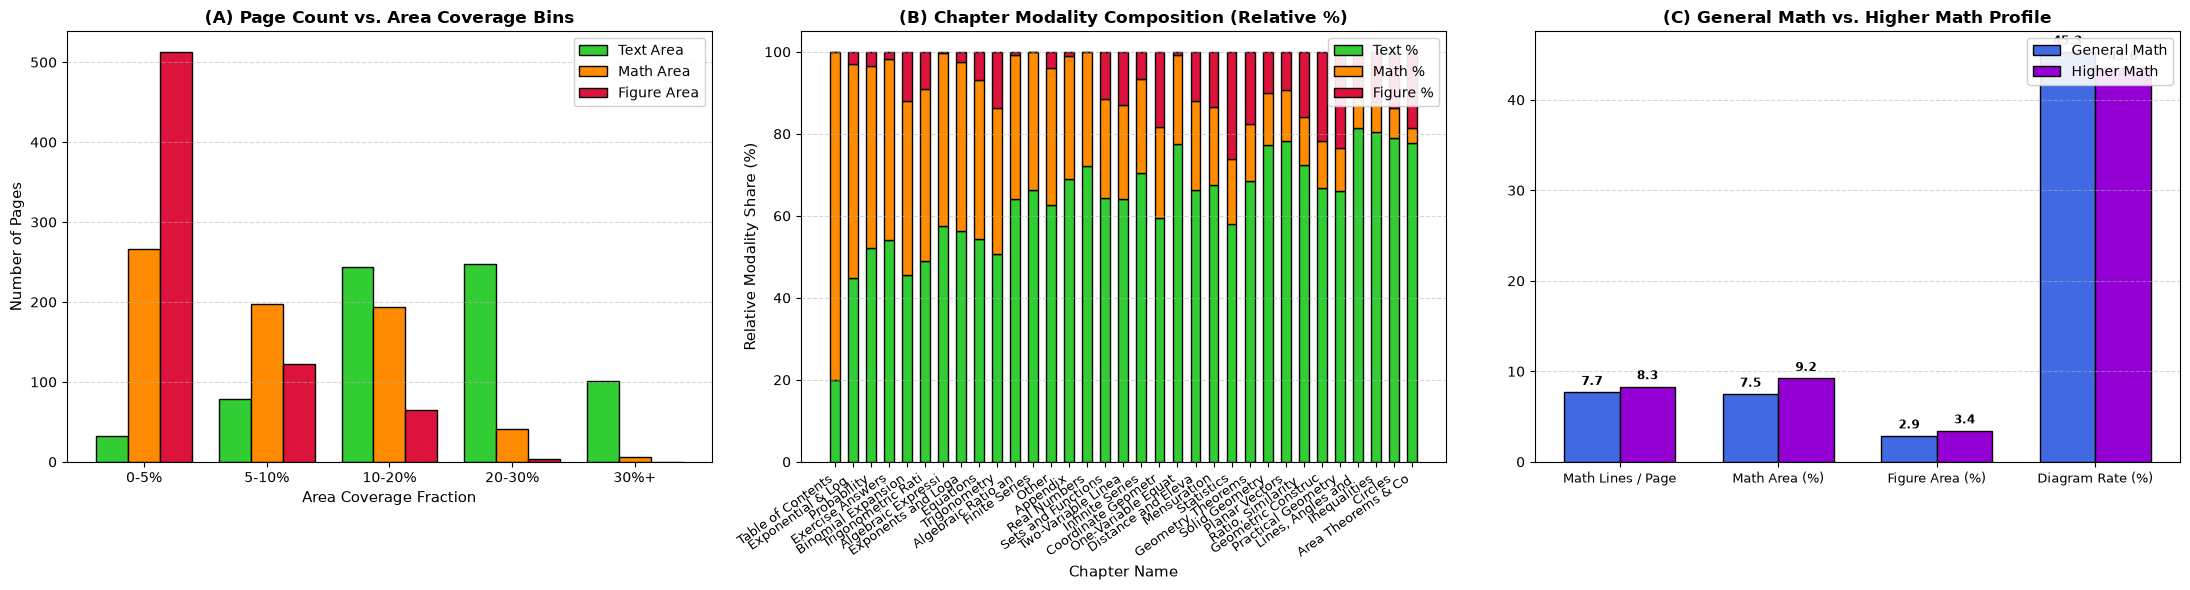

In [13]:
# Cell 5: Actionable Modality Distribution & Cross-Book Visualizations

fig, axs = plt.subplots(1, 3, figsize=(22, 6))

# Panel (A): Page Distribution vs. Modality Area Coverage (Grouped Frequency Bins)
ax = axs[0]
bins = [0.0, 0.05, 0.10, 0.20, 0.30, 1.0]
bin_labels = ["0-5%", "5-10%", "10-20%", "20-30%", "30%+"]

text_counts = pd.cut(df_metrics["text_area_frac"], bins=bins, labels=bin_labels, include_lowest=True).value_counts()[bin_labels].values
math_counts = pd.cut(df_metrics["math_area_frac"], bins=bins, labels=bin_labels, include_lowest=True).value_counts()[bin_labels].values
fig_counts = pd.cut(df_metrics["fig_area_frac"], bins=bins, labels=bin_labels, include_lowest=True).value_counts()[bin_labels].values

x = np.arange(len(bin_labels))
width = 0.26

r1 = ax.bar(x - width, text_counts, width, label="Text Area", color="limegreen", edgecolor="black")
r2 = ax.bar(x, math_counts, width, label="Math Area", color="darkorange", edgecolor="black")
r3 = ax.bar(x + width, fig_counts, width, label="Figure Area", color="crimson", edgecolor="black")

ax.set_title("(A) Page Count vs. Area Coverage Bins", fontsize=12, fontweight="bold")
ax.set_xlabel("Area Coverage Fraction", fontsize=10.5)
ax.set_ylabel("Number of Pages", fontsize=10.5)
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(loc="upper right", framealpha=0.9)

# Panel (B): Chapter-by-Chapter Modality Breakdown (Stacked Bar Chart)
ax = axs[1]
# Group by chapter (or content domain) to show distinct bars for each topic
chap_grp = df_metrics.groupby("chapter_name_en")[["text_area_frac", "math_area_frac", "fig_area_frac"]].mean()
chap_grp["total"] = chap_grp.sum(axis=1)
chap_norm = chap_grp.div(chap_grp["total"].replace(0, 1), axis=0)[["text_area_frac", "math_area_frac", "fig_area_frac"]]

# Sort by math percentage descending for clear visual interpretation
chap_norm = chap_norm.sort_values(by="math_area_frac", ascending=False)
chap_labels = [c[:18] for c in chap_norm.index]
x_ch = np.arange(len(chap_labels))
b_w = 0.55

p_txt = ax.bar(x_ch, chap_norm["text_area_frac"] * 100, b_w, label="Text %", color="limegreen", edgecolor="black")
p_mth = ax.bar(x_ch, chap_norm["math_area_frac"] * 100, b_w, bottom=chap_norm["text_area_frac"] * 100, label="Math %", color="darkorange", edgecolor="black")
p_fig = ax.bar(x_ch, chap_norm["fig_area_frac"] * 100, b_w, bottom=(chap_norm["text_area_frac"] + chap_norm["math_area_frac"]) * 100, label="Figure %", color="crimson", edgecolor="black")

ax.set_title("(B) Chapter Modality Composition (Relative %)", fontsize=12, fontweight="bold")
ax.set_xlabel("Chapter Name", fontsize=10.5)
ax.set_ylabel("Relative Modality Share (%)", fontsize=10.5)
ax.set_xticks(x_ch)
ax.set_xticklabels(chap_labels, rotation=35, ha="right", fontsize=9.5)
ax.set_ylim(0, 105)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(loc="upper right", framealpha=0.9)

# Panel (C): General Math vs. Higher Math Comparative Profile
ax = axs[2]
gm_df = df_metrics[df_metrics["book"] == "General Math"]
hm_df = df_metrics[df_metrics["book"] == "Higher Math"]

gm_stats = [
    float(gm_df["num_math"].mean()) if len(gm_df) else 0.0,
    float(gm_df["math_area_frac"].mean() * 100) if len(gm_df) else 0.0,
    float(gm_df["fig_area_frac"].mean() * 100) if len(gm_df) else 0.0,
    float((gm_df["num_figures"] >= 1).mean() * 100) if len(gm_df) else 0.0
]

hm_stats = [
    float(hm_df["num_math"].mean()) if len(hm_df) else 0.0,
    float(hm_df["math_area_frac"].mean() * 100) if len(hm_df) else 0.0,
    float(hm_df["fig_area_frac"].mean() * 100) if len(hm_df) else 0.0,
    float((hm_df["num_figures"] >= 1).mean() * 100) if len(hm_df) else 0.0
]

metric_labels = ["Math Lines / Page", "Math Area (%)", "Figure Area (%)", "Diagram Rate (%)"]
x_comp = np.arange(len(metric_labels))
c_w = 0.35

b1 = ax.bar(x_comp - c_w/2, gm_stats, c_w, label="General Math", color="royalblue", edgecolor="black")
b2 = ax.bar(x_comp + c_w/2, hm_stats, c_w, label="Higher Math", color="darkviolet", edgecolor="black")

ax.set_title("(C) General Math vs. Higher Math Profile", fontsize=12, fontweight="bold")
ax.set_xticks(x_comp)
ax.set_xticklabels(metric_labels, fontsize=9.5)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(loc="upper right", framealpha=0.9)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

plt.tight_layout()
plt.show()


In [14]:
# Cell 6: Content Archetype Classification & Orthogonal Diagram Flagging

# 1. Orthogonal Diagram / Figure Flag
df_metrics["has_diagram"] = (df_metrics["num_figures"] >= 1) | (df_metrics["fig_area_frac"] >= 0.04)

# 2. Core Structural Content Archetype Classification (3 Mutually Exclusive Types)
def classify_page_archetype(row):
    """Assigns mutually exclusive content structure archetype (Math-Heavy, Prose, Mixed)."""
    # 1. Math-Heavy / Formula Derivations
    if row["math_area_frac"] >= 0.12 or (row["num_math"] >= 5 and row["math_area_px"] > 0.5 * max(1, row["text_area_px"])):
        return "Math-Heavy / Formulas"
    
    # 2. Prose & Conceptual Theory
    if row["text_area_frac"] >= 0.28 and row["math_area_frac"] < 0.05:
        return "Prose & Theory"
    
    # 3. Mixed / Multi-Modal Composite
    return "Mixed / Multi-Modal"

df_metrics["archetype"] = df_metrics.apply(classify_page_archetype, axis=1)

# Combined multi-modal stratum for balanced stratification (Book x Archetype x Diagram)
df_metrics["stratum"] = (
    df_metrics["book"] + " — " + df_metrics["archetype"] + 
    df_metrics["has_diagram"].apply(lambda d: " [+Diagram]" if d else " [No Diagram]")
)

# Archetype & Diagram prevalence summary
arch_counts = df_metrics["archetype"].value_counts()
arch_pcts = (arch_counts / len(df_metrics)) * 100
diag_count = df_metrics["has_diagram"].sum()
diag_pct = (diag_count / len(df_metrics)) * 100

print("=" * 75)
print("             CONTENT ARCHETYPE & DIAGRAM PREVALENCE BREAKDOWN")
print("=" * 75)
print("[Content Archetypes]")
for arch in arch_counts.index:
    print(f"• {arch:<26} : {arch_counts[arch]:>3} pages ({arch_pcts[arch]:>5.1f}%)")
print("-" * 75)
print(f"[Orthogonal Flags]")
print(f"• Diagram / Figure Present : {diag_count:>3} pages ({diag_pct:>5.1f}%)")
print(f"• No Diagram / Figures     : {len(df_metrics) - diag_count:>3} pages ({100 - diag_pct:>5.1f}%)")
print("-" * 75)
print(f"Total Pages Classified     : {len(df_metrics)}")
print("=" * 75)

# Cross-tabulation: Archetype vs Diagram Presence
crosstab_diag = pd.crosstab(
    df_metrics["archetype"], 
    df_metrics["has_diagram"].map({True: "With Diagram", False: "No Diagram"}),
    margins=True
)
display(crosstab_diag)


             CONTENT ARCHETYPE & DIAGRAM PREVALENCE BREAKDOWN
[Content Archetypes]
• Mixed / Multi-Modal        : 330 pages ( 46.9%)
• Math-Heavy / Formulas      : 272 pages ( 38.6%)
• Prose & Theory             : 102 pages ( 14.5%)
---------------------------------------------------------------------------
[Orthogonal Flags]
• Diagram / Figure Present : 313 pages ( 44.5%)
• No Diagram / Figures     : 391 pages ( 55.5%)
---------------------------------------------------------------------------
Total Pages Classified     : 704


has_diagram,No Diagram,With Diagram,All
archetype,,,
Math-Heavy / Formulas,207,65,272
Mixed / Multi-Modal,125,205,330
Prose & Theory,59,43,102
All,391,313,704


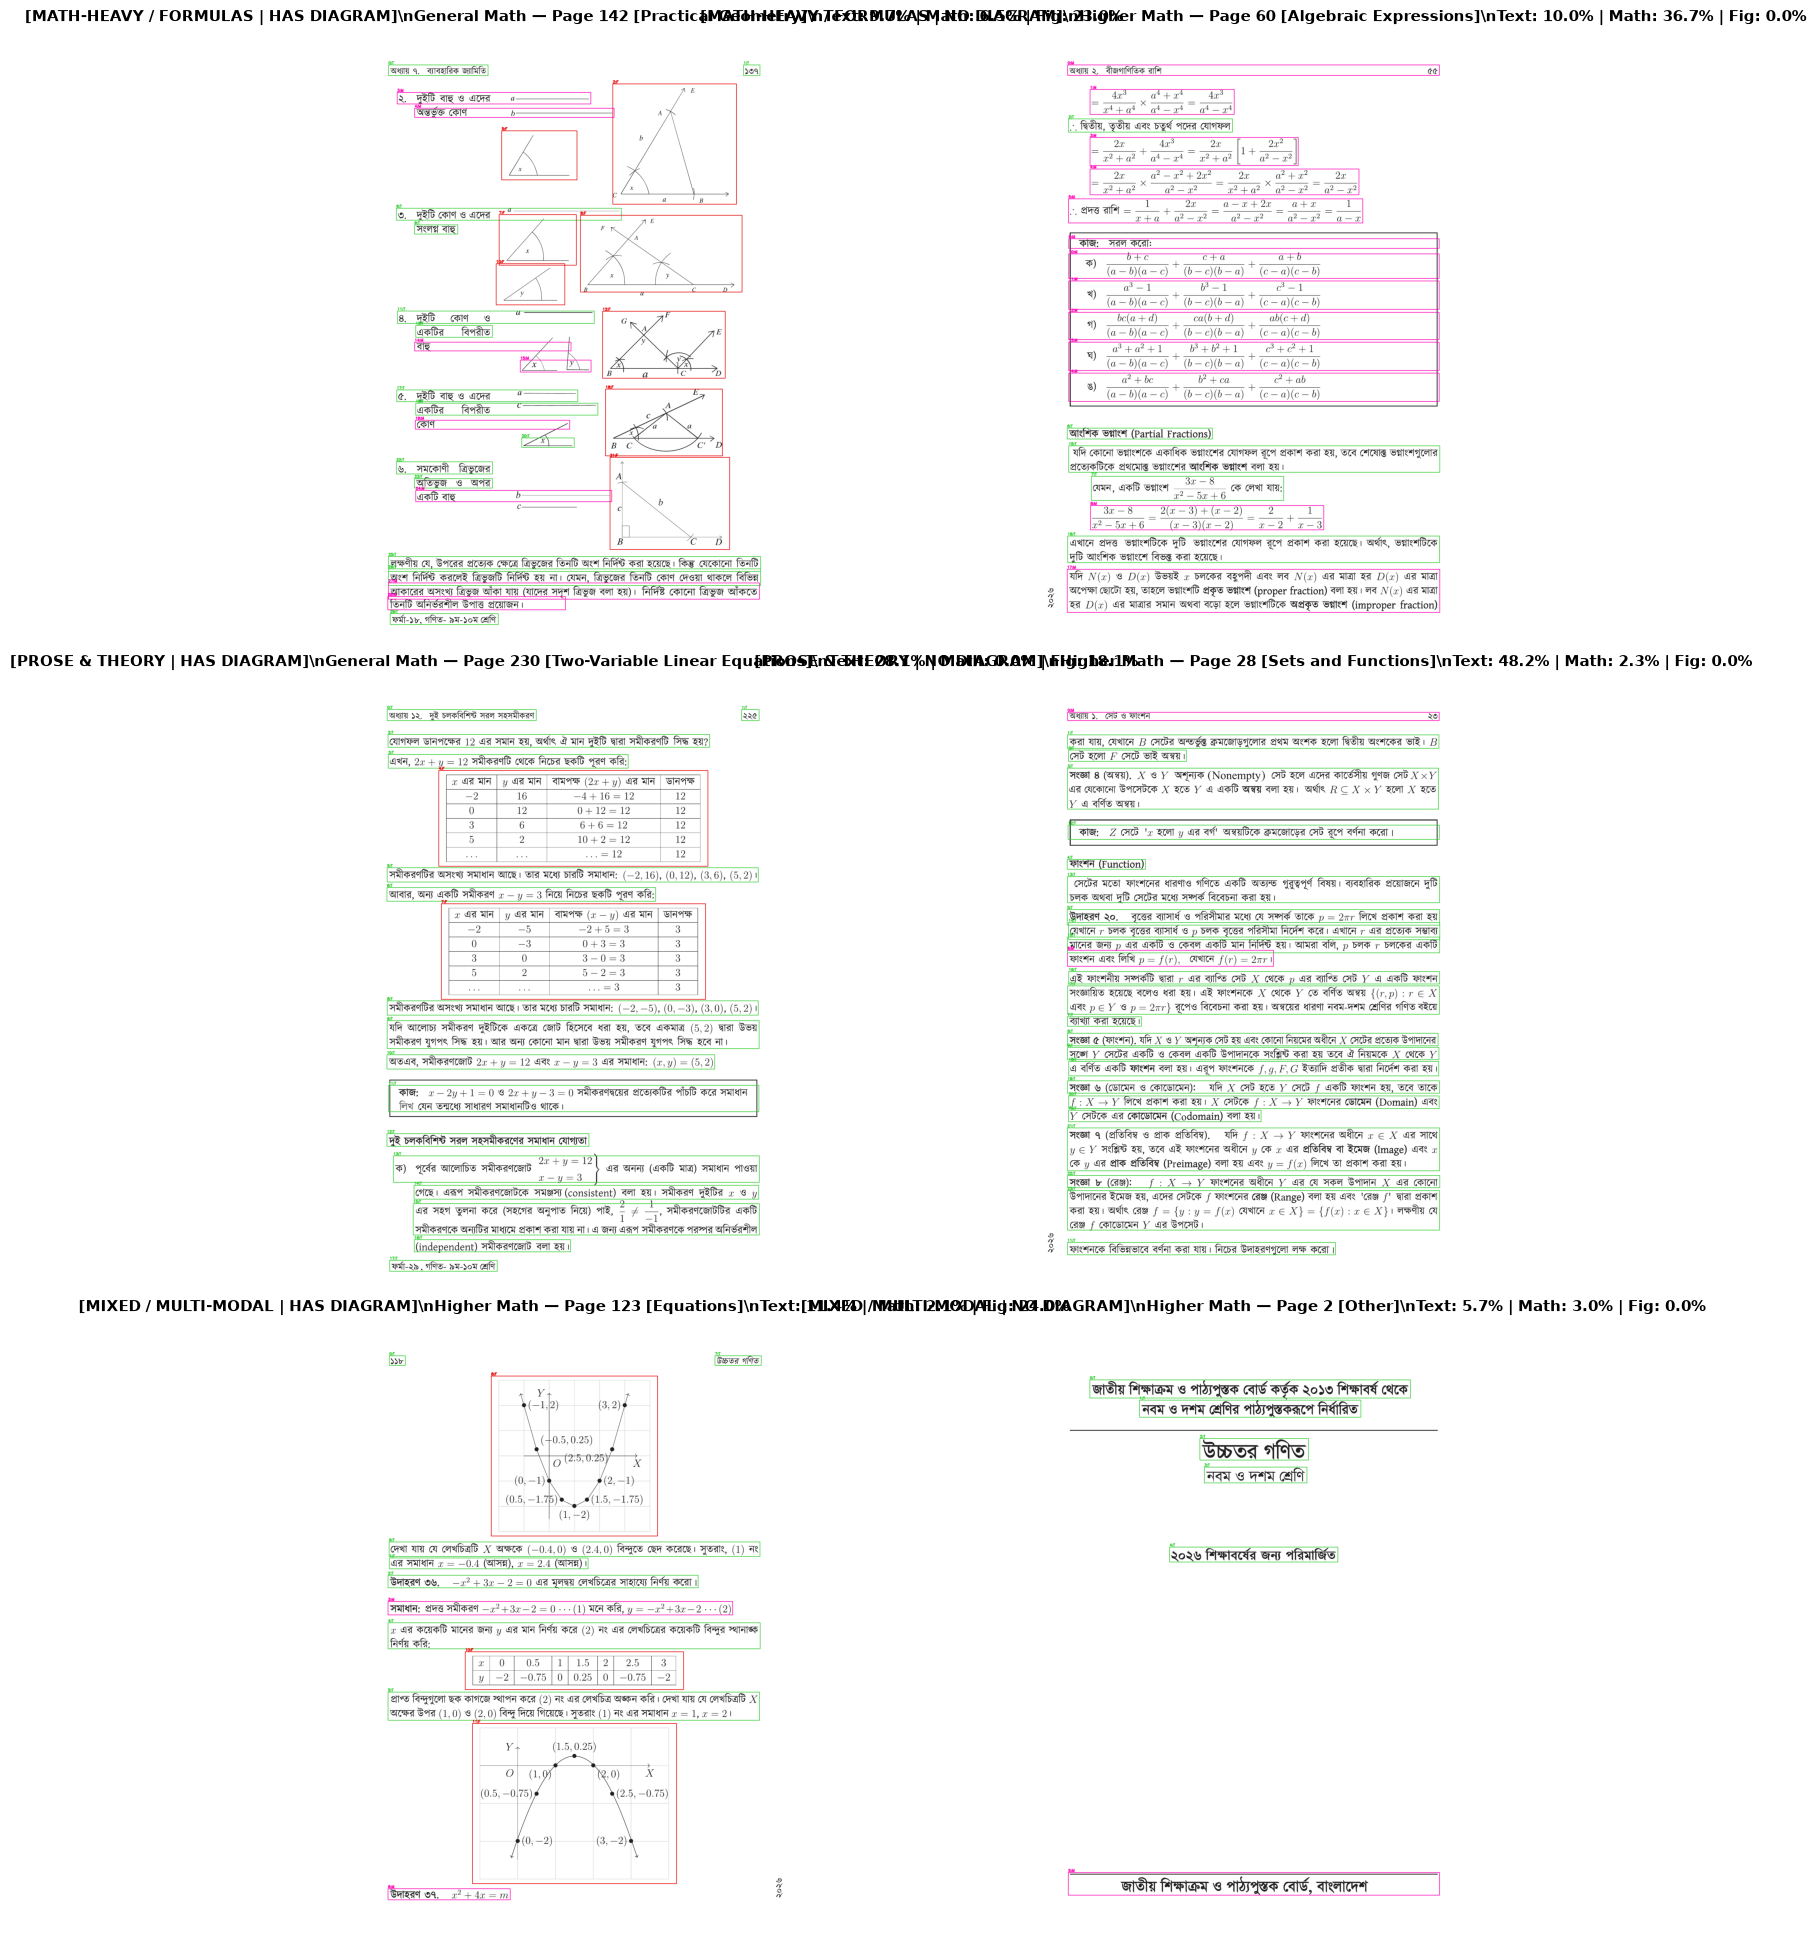

In [15]:
# Cell 7: Representative Multi-Stratum Visual Gallery

# Select representative sample pages covering each Archetype + Diagram combination
archetypes = ["Math-Heavy / Formulas", "Prose & Theory", "Mixed / Multi-Modal"]
selected_samples = []

for arch in archetypes:
    sub = df_metrics[df_metrics["archetype"] == arch]
    if sub.empty:
        continue
    
    # 1. Try to pick one with diagram (if exists)
    sub_diag = sub[sub["has_diagram"] == True]
    if not sub_diag.empty:
        best_diag = sub_diag.sort_values(by="fig_area_frac", ascending=False).iloc[0]
        selected_samples.append(best_diag)
    
    # 2. Try to pick one without diagram (if exists)
    sub_nodiag = sub[sub["has_diagram"] == False]
    if not sub_nodiag.empty:
        if arch == "Math-Heavy / Formulas":
            best_nodiag = sub_nodiag.sort_values(by="math_area_frac", ascending=False).iloc[0]
        elif arch == "Prose & Theory":
            best_nodiag = sub_nodiag.sort_values(by="text_area_frac", ascending=False).iloc[0]
        else:
            best_nodiag = sub_nodiag.iloc[0]
        selected_samples.append(best_nodiag)

n_samples = len(selected_samples)
n_cols = 2
n_rows = max(1, (n_samples + n_cols - 1) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6.5 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, sample in enumerate(selected_samples):
    ax = axes[idx]
    doc_subdir = "higher_math" if sample["book"] == "Higher Math" else "general_math"
    overlay_path = output_overlay_dir / doc_subdir / sample["filename"]
    
    if overlay_path.is_file():
        img_show = Image.open(overlay_path).convert("RGB")
    else:
        img_show = Image.open(sample["path"]).convert("RGB")
    
    ax.imshow(img_show)
    ax.axis("off")
    diag_badge = "HAS DIAGRAM" if sample["has_diagram"] else "NO DIAGRAM"
    title_text = (
        f"[{sample['archetype'].upper()} | {diag_badge}]\\n"
        f"{sample['book']} — Page {sample['page_num']} [{sample['chapter_name_en']}]\\n"
        f"Text: {sample['text_area_frac']*100:.1f}% | Math: {sample['math_area_frac']*100:.1f}% | Fig: {sample['fig_area_frac']*100:.1f}%"
    )
    ax.set_title(title_text, fontsize=10.5, fontweight='bold', pad=8)

# Hide any unused subplots
for idx in range(n_samples, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


In [16]:
# Cell 8: Stratified 90/5/5 Dataset Partitioning & Manifest Export for Grading Kit

splits_dir = Path("../data/splits") if Path("../data").is_dir() else Path("data/splits")
splits_dir.mkdir(parents=True, exist_ok=True)

# Build stratified train (90%), validation (5%), heldout (5%) splits
# Uses composite stratum (Book + Archetype + Diagram Flag) when sample counts allow
min_stratum_count = df_metrics["stratum"].value_counts().min()

if min_stratum_count >= 3 and len(df_metrics) >= 40:
    train_df, temp_df = train_test_split(
        df_metrics,
        test_size=0.10,
        random_state=42,
        stratify=df_metrics["stratum"]
    )
    val_df, heldout_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=42,
        stratify=temp_df["stratum"] if temp_df["stratum"].value_counts().min() >= 2 else None
    )
elif df_metrics["archetype"].value_counts().min() >= 2 and len(df_metrics) >= 20:
    train_df, temp_df = train_test_split(
        df_metrics,
        test_size=0.10,
        random_state=42,
        stratify=df_metrics["archetype"]
    )
    val_df, heldout_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=42
    )
else:
    train_df, temp_df = train_test_split(df_metrics, test_size=0.10, random_state=42)
    val_df, heldout_df = train_test_split(temp_df, test_size=0.50, random_state=42)

def to_split_dict(df_split):
    records = []
    for _, row in df_split.iterrows():
        records.append({
            "page_id": row["page_id"],
            "filename": row["filename"],
            "image_path": row["path"],
            "book": row["book"],
            "page_num": int(row["page_num"]),
            "chapter_id": row["chapter_id"],
            "chapter_name_bn": row["chapter_name_bn"],
            "chapter_name_en": row["chapter_name_en"],
            "content_type": row["content_type"],
            "archetype": row["archetype"],
            "has_diagram": bool(row["has_diagram"]),
            "metrics": {
                "fig_area_frac": float(row["fig_area_frac"]),
                "math_area_frac": float(row["math_area_frac"]),
                "text_area_frac": float(row["text_area_frac"]),
                "est_words": int(row["est_words"])
            }
        })
    return records

train_records = to_split_dict(train_df)
val_records = to_split_dict(val_df)
heldout_records = to_split_dict(heldout_df)

train_path = splits_dir / "train.json"
val_path = splits_dir / "val.json"
heldout_path = splits_dir / "heldout.json"
summary_path = splits_dir / "summary.csv"

with open(train_path, "w", encoding="utf-8") as f:
    json.dump(train_records, f, indent=2, ensure_ascii=False)

with open(val_path, "w", encoding="utf-8") as f:
    json.dump(val_records, f, indent=2, ensure_ascii=False)

with open(heldout_path, "w", encoding="utf-8") as f:
    json.dump(heldout_records, f, indent=2, ensure_ascii=False)

# Summary distribution table
split_summary = pd.DataFrame({
    "Train (90%)": train_df["archetype"].value_counts(),
    "Val (5%)": val_df["archetype"].value_counts(),
    "Held-Out Test (5%)": heldout_df["archetype"].value_counts(),
}).fillna(0).astype(int)

split_summary.loc["Total"] = split_summary.sum()
split_summary.to_csv(summary_path)

# Diagram summary in splits
diag_split_summary = pd.DataFrame({
    "Train (90%)": train_df["has_diagram"].value_counts(),
    "Val (5%)": val_df["has_diagram"].value_counts(),
    "Held-Out Test (5%)": heldout_df["has_diagram"].value_counts(),
}).rename(index={True: "Has Diagram", False: "No Diagram"}).fillna(0).astype(int)

print("=" * 75)
print("             STRATIFIED DATASET SPLIT SUMMARY (90/5/5)")
print("=" * 75)
print("[Archetype Distribution in Splits]")
display(split_summary)
print("-" * 75)
print("[Diagram Presence Distribution in Splits]")
display(diag_split_summary)
print("-" * 75)
print(f"• Train Set Manifest   : {train_path.resolve()} ({len(train_records)} pages)")
print(f"• Validation Manifest  : {val_path.resolve()} ({len(val_records)} pages)")
print(f"• Held-Out Kit Manifest: {heldout_path.resolve()} ({len(heldout_records)} pages)")
print(f"• Summary Distribution : {summary_path.resolve()}")
print("=" * 75)


             STRATIFIED DATASET SPLIT SUMMARY (90/5/5)
[Archetype Distribution in Splits]


,Train (90%),Val (5%),Held-Out Test (5%)
archetype,,,
Math-Heavy / Formulas,244,14,14
Mixed / Multi-Modal,298,14,18
Prose & Theory,91,7,4
Total,633,35,36


---------------------------------------------------------------------------
[Diagram Presence Distribution in Splits]


,Train (90%),Val (5%),Held-Out Test (5%)
has_diagram,,,
No Diagram,352,19,20
Has Diagram,281,16,16


---------------------------------------------------------------------------
• Train Set Manifest   : E:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\data\splits\train.json (633 pages)
• Validation Manifest  : E:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\data\splits\val.json (35 pages)
• Held-Out Kit Manifest: E:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\data\splits\heldout.json (36 pages)
• Summary Distribution : E:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\data\splits\summary.csv
